In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

### show the dataset

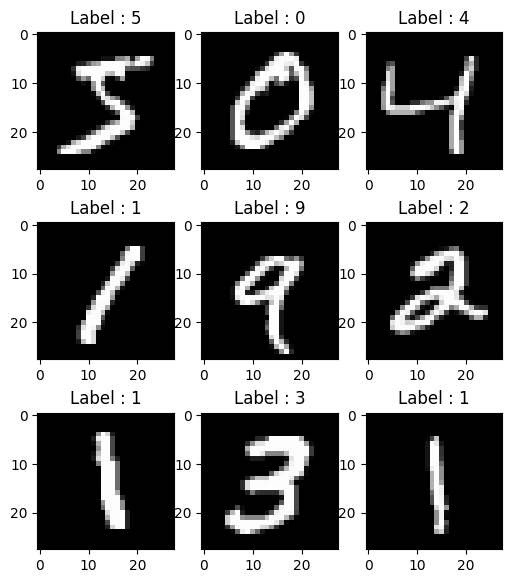

In [3]:
import matplotlib.pyplot as plt

def show_images(images, labels, num=5):
    plt.figure(figsize=(6,7))
    for i in range(num):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label : {labels[i]}")
    plt.show()

show_images(x_train, y_train, 9)

### Preprocessing of the data

In [4]:
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0

Define the model

In [5]:
model = models.Sequential([
    #hidden layer 1
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # hidden layer 2
    layers.Dense(64, activation='relu'),
    #output layer 
    layers.Dense(10, activation='softmax')
])

C:\Users\angaj\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model

<Sequential name=sequential, built=True>

### Compile the Model

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Train the model

In [8]:
model.fit(x_train, y_train, epochs=10, batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9203 - loss: 0.2791
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9651 - loss: 0.1159
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9758 - loss: 0.0802
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9815 - loss: 0.0607
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9852 - loss: 0.0465
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9882 - loss: 0.0374
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9901 - loss: 0.0306
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9922 - loss: 0.0254
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9926 - loss: 0.0219
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9934 - loss: 0.0201


In [9]:
### Model Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0876


## Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

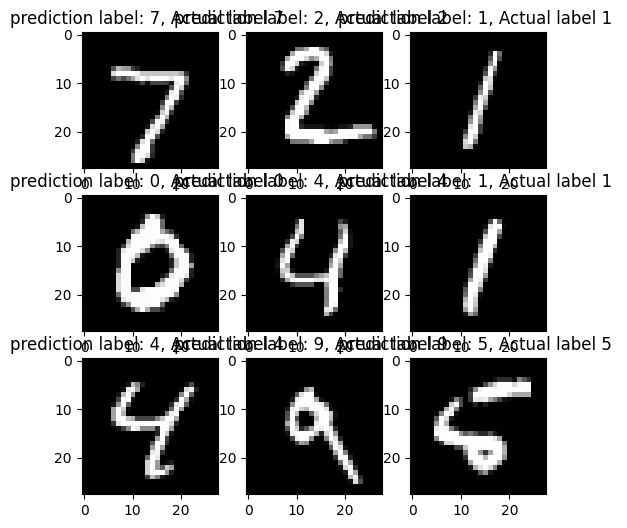

In [13]:
import numpy as np
predictons = model.predict(x_test[:9])
predicted_labels = np.argmax(predictons, axis=1)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3, 3, i+1),
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"prediction label: {predicted_labels[i]}, Actual label {y_test[i]} ")
plt.show